# 16 — Lead–lag compensators (`math`, SciPy, PyTorch, python-control)

Type-1 plant with skinny phase margin:

$$
G(s) = \frac{12}{s(s+1)}
$$

A lead

$$
C_\\mathrm{lead}(s) = \\frac{s/z + 1}{s/p + 1},\\qquad p > z
$$

adds phase around crossover (less overshoot). A lag raises low-frequency gain (smaller \(e_{ss}\) to a ramp) without moving crossover much. The GPU batches many lead *pole/zero ratios*.

In [1]:
from __future__ import annotations

import math
import time

import control as ct
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy import signal

%matplotlib inline

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"python-control {ct.__version__}   torch {torch.__version__}   device {device}")
if device.type == "cuda":
    print(f"CUDA {torch.version.cuda}  |  {torch.cuda.get_device_name(0)}")


python-control 0.10.2   torch 2.14.0+cu132   device cuda
CUDA 13.2  |  NVIDIA GeForce RTX 3060


In [2]:
def bode_mag_phase(sys, omega):
    frd = ct.frequency_response(sys, omega=omega)
    if hasattr(frd, "magnitude"):
        w = np.asarray(frd.frequency).reshape(-1)
        m = np.asarray(frd.magnitude).reshape(-1)
        p = np.asarray(frd.phase).reshape(-1)
    else:
        mag, phase, om = frd
        w = np.asarray(om).reshape(-1)
        m = np.asarray(mag).reshape(-1)
        p = np.asarray(phase).reshape(-1)
    return w, m, p


def plot_bode(sys, title, marks=()):
    w, m, p = bode_mag_phase(sys, np.logspace(0, 5, 500))
    fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
    axes[0].semilogx(w / (2 * np.pi), 20 * np.log10(np.maximum(m, 1e-16)))
    axes[1].semilogx(w / (2 * np.pi), np.degrees(np.unwrap(p)))
    for f, lab in marks:
        axes[0].axvline(f, color="k", ls="--", lw=1, label=lab)
        axes[1].axvline(f, color="k", ls="--", lw=1)
    axes[0].set_ylabel("mag (dB)")
    axes[1].set_ylabel("phase (deg)")
    axes[1].set_xlabel("frequency (Hz)")
    for ax in axes:
        ax.grid(True, which="both", alpha=0.3)
    if marks:
        axes[0].legend()
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()
    return w, m, p


def max_abs(a, b) -> float:
    return float(np.max(np.abs(np.asarray(a, dtype=np.float64) - np.asarray(b, dtype=np.float64))))


In [3]:
FS_HZ = 512
DURATION_S = 6.0
N = int(FS_HZ * DURATION_S)
DT = 1.0 / FS_HZ
Z_LEAD, P_LEAD = 1.0, 8.0

t = np.arange(N, dtype=np.float64) / FS_HZ
r = np.ones(N, dtype=np.float64)
print(f"n = {N}   dt = {DT:.6f} s   device = {device}")

n = 3072   dt = 0.001953 s   device = cuda


## python-control — uncompensated vs lead

uncompensated    PM= 16.42 deg   wgc=3.393 rad/s   GM=inf
lead             PM= 43.88 deg   wgc=8.318 rad/s   GM=inf
overshoot ol=63.2%  lead=24.5%


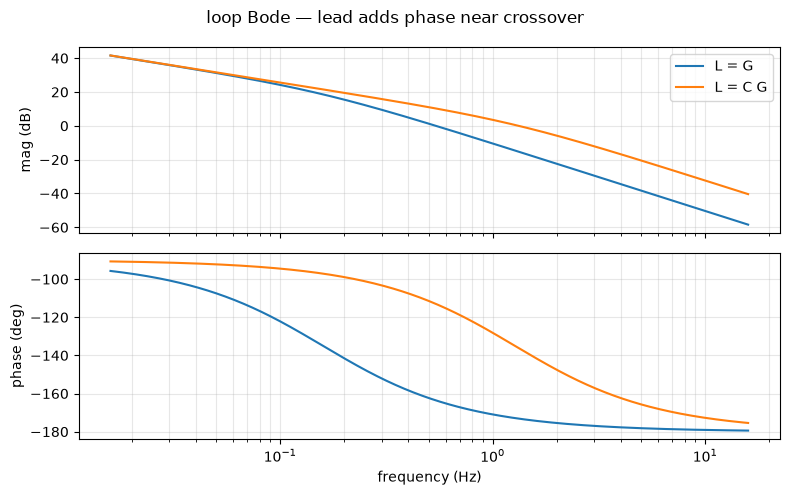

In [4]:
G = ct.tf([12.0], [1.0, 1.0, 0.0])
C_lead = ct.tf([1.0 / Z_LEAD, 1.0], [1.0 / P_LEAD, 1.0])
L_ol = G
L_ld = C_lead * G
T_ol = ct.feedback(L_ol, 1)
T_ld = ct.feedback(L_ld, 1)

for name, L in (("uncompensated", L_ol), ("lead", L_ld)):
    gm, pm, _a, wgc = ct.margin(L)
    print(f"{name:16} PM={pm:6.2f} deg   wgc={wgc:.3f} rad/s   GM={gm}")

_, y_ol = ct.forced_response(T_ol, T=t, U=r)
_, y_ld = ct.forced_response(T_ld, T=t, U=r)
print(f"overshoot ol={(y_ol.max()-1)*100:.1f}%  lead={(y_ld.max()-1)*100:.1f}%")

w, m_ol, p_ol = bode_mag_phase(L_ol, np.logspace(-1, 2, 500))
_, m_ld, p_ld = bode_mag_phase(L_ld, np.logspace(-1, 2, 500))
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
axes[0].semilogx(w / (2 * np.pi), 20 * np.log10(np.maximum(m_ol, 1e-16)), label="L = G")
axes[0].semilogx(w / (2 * np.pi), 20 * np.log10(np.maximum(m_ld, 1e-16)), label="L = C G")
axes[1].semilogx(w / (2 * np.pi), np.degrees(np.unwrap(p_ol)))
axes[1].semilogx(w / (2 * np.pi), np.degrees(np.unwrap(p_ld)))
axes[0].set_ylabel("mag (dB)")
axes[1].set_ylabel("phase (deg)")
axes[1].set_xlabel("frequency (Hz)")
axes[0].legend()
for ax in axes:
    ax.grid(True, which="both", alpha=0.3)
fig.suptitle("loop Bode — lead adds phase near crossover")
fig.tight_layout()
plt.show()

## `math` — series Euler of lead + type-1 plant

Lead \(C(s)=(\tau_z s+1)/(\tau_p s+1)\) in controllable form without differentiating \(e\): \(\dot{x}_c = -x_c/\tau_p + e\), \(u = (\tau_z/\tau_p)\,e + (1-\tau_z/\tau_p)\,x_c/\tau_p\). Plant: \(\ddot{y}+\dot{y}=12u\).

In [5]:
def math_lead_closed(r_list, dt, z, p, k_plant=12.0):
    tz, tp = 1.0 / z, 1.0 / p
    ratio = tz / tp
    x1 = 0.0
    x2 = 0.0
    xc = 0.0
    y = 0.0
    out = []
    for r_n in r_list:
        e = r_n - y
        u = ratio * e + (1.0 - ratio) * (xc / tp)
        xc = xc + dt * (-xc / tp + e)
        dx1 = x2
        dx2 = -x2 + k_plant * u
        x1 = x1 + dt * dx1
        x2 = x2 + dt * dx2
        y = x1
        out.append(y)
    return out


y_math = math_lead_closed(r.tolist(), DT, Z_LEAD, P_LEAD)
print(f"math vs control lead {max_abs(y_ld, y_math):.3e}")

math vs control lead 1.497e-02


## SciPy — `lsim` of `tf2ss(T_lead)`

In [6]:
ss_ld = ct.tf2ss(T_ld)
_tout, y_sp, _x = signal.lsim(signal.StateSpace(ss_ld.A, ss_ld.B, ss_ld.C, ss_ld.D), U=r, T=t)
y_sp = np.asarray(y_sp).reshape(-1)
print(f"scipy vs control {max_abs(y_ld, y_sp):.3e}")

scipy vs control 2.442e-15


## PyTorch — batched lead ratio \(p/z\)

Fix the zero at \(z=1\,\mathrm{rad/s}\), sweep the pole. Each batch item is a different compensator on the same plant, states on `cuda`.

In [7]:
def torch_lead_batch(r_t, dt, z, p, k_plant=12.0):
    # r_t: (T,), z scalar, p: (B,)
    B = p.numel()
    T = r_t.numel()
    r_b = r_t.expand(B, T)
    tz = 1.0 / z
    tp = 1.0 / p
    ratio = tz / tp
    x1 = torch.zeros(B, device=r_t.device, dtype=r_t.dtype)
    x2 = torch.zeros(B, device=r_t.device, dtype=r_t.dtype)
    xc = torch.zeros(B, device=r_t.device, dtype=r_t.dtype)
    y = torch.zeros(B, device=r_t.device, dtype=r_t.dtype)
    out = torch.empty(B, T, device=r_t.device, dtype=r_t.dtype)
    for i in range(T):
        e = r_b[:, i] - y
        u = ratio * e + (1.0 - ratio) * (xc / tp)
        xc = xc + dt * (-xc / tp + e)
        dx1 = x2
        dx2 = -x2 + k_plant * u
        x1 = x1 + dt * dx1
        x2 = x2 + dt * dx2
        y = x1
        out[:, i] = y
    return out


r_th = torch.as_tensor(r, device=device, dtype=torch.float32)
p_grid = torch.linspace(2.0, 16.0, 20, device=device, dtype=torch.float32)
if device.type == "cuda":
    torch.cuda.synchronize()
t0 = time.perf_counter()
y_batch = torch_lead_batch(r_th, DT, Z_LEAD, p_grid)
if device.type == "cuda":
    torch.cuda.synchronize()
print(f"lead batch {tuple(y_batch.shape)} on {y_batch.device} in {(time.perf_counter()-t0)*1e3:.1f} ms")
i_nom = int(torch.argmin(torch.abs(p_grid - P_LEAD)).item())
y_gpu = y_batch[i_nom].detach().cpu().numpy()
print(f"nom p={float(p_grid[i_nom]):.2f}  math vs torch {max_abs(y_math, y_gpu):.3e}")

lead batch (20, 3072) on cuda:0 in 498.3 ms
nom p=7.89  math vs torch 5.368e-03


## Overlay + lag note

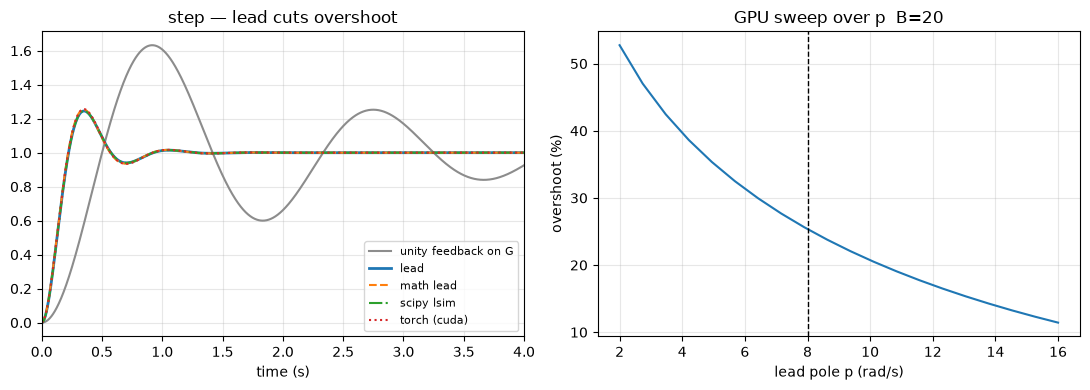

lag example (K=3 on 4/s(s+1)) final=1.0009  overshoot=69.3%


In [8]:
C_lag = 3.0 * ct.tf([1.0, 0.2], [1.0, 0.05])
T_lag = ct.feedback(C_lag * ct.tf([4.0], [1.0, 1.0, 0.0]), 1)
_, y_lag = ct.forced_response(T_lag, T=t, U=r)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t, y_ol, color="0.55", label="unity feedback on G")
axes[0].plot(t, y_ld, lw=2.0, label="lead")
axes[0].plot(t, y_math, ls="--", label="math lead")
axes[0].plot(t, y_sp, ls="-.", label="scipy lsim")
axes[0].plot(t, y_gpu, ls=":", label=f"torch ({device})")
axes[0].set_xlim(0, 4)
axes[0].set_xlabel("time (s)")
axes[0].set_title("step — lead cuts overshoot")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

os = (y_batch.max(dim=1).values - 1.0).clamp(min=0).detach().cpu().numpy() * 100
axes[1].plot(p_grid.detach().cpu().numpy(), os)
axes[1].axvline(P_LEAD, color="k", ls="--", lw=1)
axes[1].set_xlabel("lead pole p (rad/s)")
axes[1].set_ylabel("overshoot (%)")
axes[1].set_title(f"GPU sweep over p  B={p_grid.numel()}")
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()
print(f"lag example (K=3 on 4/s(s+1)) final={y_lag[-1]:.4f}  overshoot={(y_lag.max()-1)*100:.1f}%")

## Takeaways

- Lead buys phase margin near \(w_{gc}\); the step overshoot drops (here ~63% → ~25%).
- Lag is a low-frequency gain tool — do not use it to "fix" a thin PM.
- `math` / torch Euler of the compensator+plant tracks python-control when \(f_s\) is high.
- GPU work is a **compensator parameter sweep**. Next (`17`): drop TFs and stay in **state space**.